In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


In [2]:
# Load local dataset (MODIFIED: use workspace file instead of /content path)
df = pd.read_csv("dataset.csv")
# MODIFIED: ensure file path matches the repository dataset.csv

In [4]:
df.head()

,URL,Label
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad
3,mail.printakid.com/www.online.americanexpress....,bad
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad


In [5]:
df.shape

(549346, 2)

In [6]:
# for imbalance function
df.Label.value_counts()

Label
good    392924
bad     156422
Name: count, dtype: int64

In [7]:
# tokenization

from nltk.tokenize import RegexpTokenizer

tokenizer = RegexpTokenizer(r'[A-Za-z]+')
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\laxmi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [8]:
df.URL[0]

'nobell.it/70ffb52d079109dca5664cce6f317373782/login.SkyPe.com/en/cgi-bin/verification/login/70ffb52d079109dca5664cce6f317373/index.php?cmd=_profile-ach&outdated_page_tmpl=p/gen/failed-to-load&nav=0.5.1&login_access=1322408526'

In [9]:
tokenizer.tokenize(df.URL[0])

['nobell',
 'it',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'login',
 'SkyPe',
 'com',
 'en',
 'cgi',
 'bin',
 'verification',
 'login',
 'ffb',
 'd',
 'dca',
 'cce',
 'f',
 'index',
 'php',
 'cmd',
 'profile',
 'ach',
 'outdated',
 'page',
 'tmpl',
 'p',
 'gen',
 'failed',
 'to',
 'load',
 'nav',
 'login',
 'access']

In [10]:
df['tokenized'] = df.URL.map(lambda x: tokenizer.tokenize(x))

In [11]:
df.head()

,URL,Label,tokenized
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi..."


In [12]:
from nltk.stem.snowball import SnowballStemmer

In [13]:
stemmer = SnowballStemmer("english")

In [14]:
df['stemmed'] = df['tokenized'].map(lambda x: [stemmer.stem(y) for y in x])

In [15]:
df.head()

,URL,Label,tokenized,stemmed
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,..."
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin..."
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into..."
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp..."
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide..."


In [16]:
df['test'] = df['stemmed'].map(lambda x: ' '.join(x))

In [17]:
df.head()

,URL,Label,tokenized,stemmed,test
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [18]:
good_sites = df[df.Label == 'good']
bad_sites = df[df.Label == 'bad']

In [19]:
good_sites.head()

,URL,Label,tokenized,stemmed,test
18231,esxcc.com/js/index.htm?us.battle.net/noghn/en/...,good,"[esxcc, com, js, index, htm, us, battle, net, ...","[esxcc, com, js, index, htm, us, battl, net, n...",esxcc com js index htm us battl net noghn en r...
18232,wwweira¯&nvinip¿ncH¯wVö%ÆåyDaHðû/ÏyEùuË\nÓ6...,good,"[www, eira, nvinip, ncH, wV, yDaH, yE, u, rT, ...","[www, eira, nvinip, nch, wv, ydah, ye, u, rt, ...",www eira nvinip nch wv ydah ye u rt u g m i xz...
18233,'www.institutocgr.coo/web/media/syqvem/dk-óij...,good,"[www, institutocgr, coo, web, media, syqvem, d...","[www, institutocgr, coo, web, media, syqvem, d...",www institutocgr coo web media syqvem dk ij r ...
18234,Yìê koãÕ»Î§DéÎl½ñ¡ââqtò¸/à; Í,good,"[Y, ko, D, l, qt]","[y, ko, d, l, qt]",y ko d l qt
18236,ruta89fm.com/images/AS@Vies/1i75cf7b16vc<Fd16...,good,"[ruta, fm, com, images, AS, Vies, i, cf, b, vc...","[ruta, fm, com, imag, as, vie, i, cf, b, vc, f...",ruta fm com imag as vie i cf b vc f d b g sd v...


In [20]:
def plot_wordcloud(text, mask=None, max_words=400, max_font_size=120, figure_size=(24.0, 16.0),
                   title = None, title_size= 40, image_color = False):
  stepwords = set(STOPWORDS)
  more_stopwords = {'com', 'http'}
  stopwords = stepwords.union(more_stopwords)

  wordcloud = WordCloud(background_color='white',
                        stopwords = stopwords,
                        max_words = max_words,
                        max_font_size = max_font_size,
                        random_state = 42,
                        mask = mask)
  wordcloud.generate(text)

  plt.figure(figsize=figure_size)
  if image_color:
    image_colors = ImageColorGenerator(mask);
    plt.imshow(wordcloud.recolor(color_func=image_colors), interpolation="bilinear");
    plt.title(title, fontdict={'size': title_size,
                              'verticalalignment': 'bottom'})
  else:
    plt.imshow(wordcloud);
    plt.title(title, fontdict={'size': title_size, 'color': 'green',
                               'verticalalignment': 'bottom'})
  plt.axis('off');
  plt.tight_layout()
  plt.show();


In [21]:
all_text = ' '.join(good_sites['test'].tolist())

In [22]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

In [23]:
# for visualisation , which data is maximum used for good sites


In [24]:
# generate word cloud
wordcloud = WordCloud(background_color='white',width=800, height=400).generate(all_text)

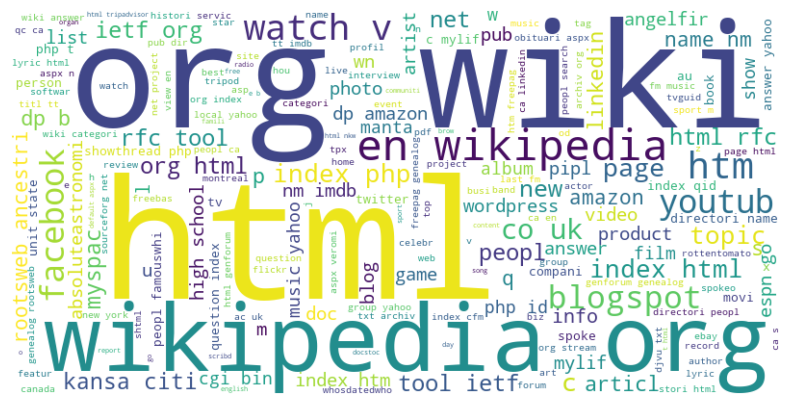

In [25]:
# ḍisplay the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [26]:
all_text = ' '.join(bad_sites['test'].tolist())

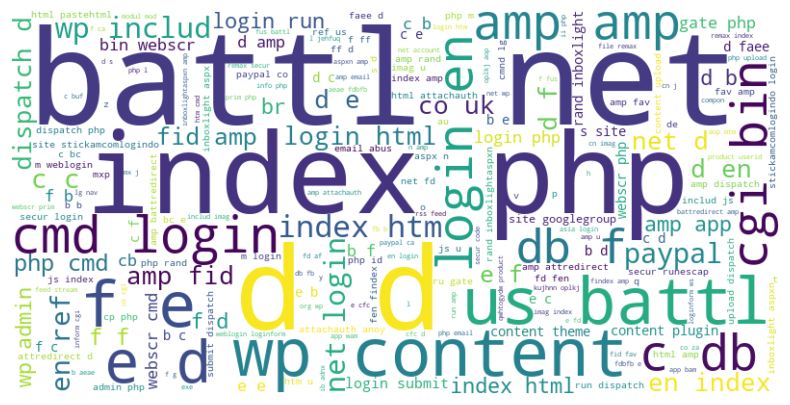

In [27]:
# generate word cloud
wordcloud = WordCloud(background_color='white',width=800, height=400).generate(all_text)
# ḍisplay the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [28]:
# for converting these words in form of vector

In [29]:
df.head()

,URL,Label,tokenized,stemmed,test
0,nobell.it/70ffb52d079109dca5664cce6f317373782/...,bad,"[nobell, it, ffb, d, dca, cce, f, login, SkyPe...","[nobel, it, ffb, d, dca, cce, f, login, skype,...",nobel it ffb d dca cce f login skype com en cg...
1,www.dghjdgf.com/paypal.co.uk/cycgi-bin/webscrc...,bad,"[www, dghjdgf, com, paypal, co, uk, cycgi, bin...","[www, dghjdgf, com, paypal, co, uk, cycgi, bin...",www dghjdgf com paypal co uk cycgi bin webscrc...
2,serviciosbys.com/paypal.cgi.bin.get-into.herf....,bad,"[serviciosbys, com, paypal, cgi, bin, get, int...","[serviciosbi, com, paypal, cgi, bin, get, into...",serviciosbi com paypal cgi bin get into herf s...
3,mail.printakid.com/www.online.americanexpress....,bad,"[mail, printakid, com, www, online, americanex...","[mail, printakid, com, www, onlin, americanexp...",mail printakid com www onlin americanexpress c...
4,thewhiskeydregs.com/wp-content/themes/widescre...,bad,"[thewhiskeydregs, com, wp, content, themes, wi...","[thewhiskeydreg, com, wp, content, theme, wide...",thewhiskeydreg com wp content theme widescreen...


In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

# MODIFIED: use TF-IDF on character n-grams (non-negative feature values),
# increased max_features for better representation
vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3,5),
    max_features=20000
)

features = vectorizer.fit_transform(df['test'])
# MODIFIED: features are TF-IDF vectors stored in `features`

In [31]:
# NOTE: HashingVectorizer removed to avoid negative feature issues with MultinomialNB
# MODIFIED: Using TF-IDF vectorizer (defined earlier) which yields non-negative values
# If you need a memory-efficient, streaming vectorizer consider HashingVectorizer but then
# you'll need to transform negatives to zero before using MultinomialNB.

In [32]:
TfidfVectorizer(analyzer='char', ngram_range=(3,5))

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'char'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(3

In [33]:
features[:5].toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.10739412, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(5, 20000))

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# MODIFIED: encode labels to numeric and use stratified split for class balance
le = LabelEncoder()
y = le.fit_transform(df.Label)  # bad->0, good->1 (verify with le.classes_)
x_train, x_test, y_train, y_test = train_test_split(features, y, test_size=0.3, stratify=y, random_state=42)
# MODIFIED: stratify=y ensures train/test have same label proportions; random_state for reproducibility

In [35]:
x_train, x_test, y_train, y_test = train_test_split(features,df.Label,test_size=0.3)

In [36]:
x_train.shape

(384542, 20000)

In [37]:
x_test.shape

(164804, 20000)

`Model Training`

In [38]:
from sklearn.linear_model import LogisticRegression
# MODIFIED: configure LogisticRegression for convergence and class imbalance
# - increased max_iter, - use 'saga' solver which handles large sparse data,
# - class_weight='balanced' helps with imbalanced labels
model = LogisticRegression(max_iter=1000, solver='saga', class_weight='balanced', random_state=42)

In [39]:
model = LogisticRegression()

In [40]:
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [41]:
model.score(x_test,y_test)

0.9566758088395912

In [42]:

model.score(x_train,y_train)

0.9607637137165771

In [43]:
from sklearn.metrics import classification_report

In [44]:
print('\nCLASSIFICATION REPORT')

print(classification_report(y_test,model.predict(x_test), target_names=['bad','good']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

         bad       0.95      0.90      0.92     46770
        good       0.96      0.98      0.97    118034

    accuracy                           0.96    164804
   macro avg       0.95      0.94      0.95    164804
weighted avg       0.96      0.96      0.96    164804



In [45]:
from sklearn.metrics import confusion_matrix

In [46]:
con_mat = pd.DataFrame(confusion_matrix(y_test,model.predict(x_test)),columns=['Predicted:BAD', 'Predicted:GOOD'],index=['Actual:BAD', 'Actual:GOOD'])


 CONFUSION MATRIX


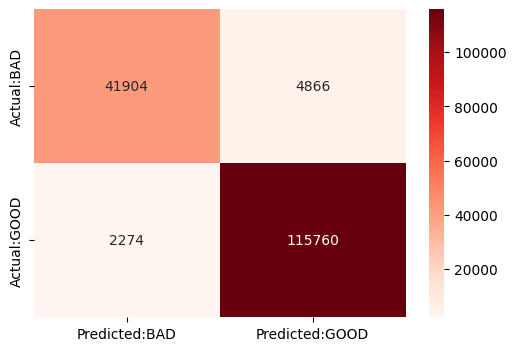

In [56]:
print('\n CONFUSION MATRIX')
plt.figure(figsize=(6,4))
sns.heatmap(con_mat, annot=True, fmt='d', cmap='Reds')
plt.show()

In [48]:
from sklearn.naive_bayes import MultinomialNB

In [49]:
modell = MultinomialNB()

In [50]:
import numpy as np

# The HashingVectorizer used previously can produce negative values,
# which MultinomialNB does not support. Use TF-IDF (non-negative) by default,
# but be robust: coerce any negative entries to zero for both dense and sparse formats.
# MODIFIED: robust non-negative conversion for x_train
x_train_non_negative = x_train.copy()
try:
    x_train_non_negative[x_train_non_negative < 0] = 0
except Exception:
    # sparse matrix path: modify the underlying data array
    x_train_non_negative.data[x_train_non_negative.data < 0] = 0

# Fit the model on the non-negative training data
modell.fit(x_train_non_negative, y_train)
# MODIFIED: trained on non-negative features to satisfy MultinomialNB requirements

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [51]:
# MODIFIED: ensure non-negative test features when using MultinomialNB (if vectorizer produced negatives)
x_test_non_negative = x_test.copy()
try:
    x_test_non_negative[x_test_non_negative < 0] = 0
except Exception:
    # For sparse matrices set negative data entries to zero in-place
    x_test_non_negative.data[x_test_non_negative.data < 0] = 0
modell.score(x_test_non_negative, y_test)
# MODIFIED: used x_test_non_negative for scoring to match training preprocessing

0.91598504890658

In [57]:
import pickle

pickle.dump(model,open('phishing.pkl','wb'))

In [58]:
pickle.dump(vectorizer, open('vectorizer.pkl', 'wb'))

In [59]:
pickle.dump(modell,open('phishing_mnb.pkl','wb'))